# 方案3：专注于实际的"草地纹理"的预处理步骤

## 概述

本方案专注于解决农业图像处理中的关键预处理问题，特别是针对CSIRO生物量预测竞赛中的图像质量问题。通过系统性的预处理步骤，我们可以显著提高模型性能，避免模型学习到无关的伪影特征。

## 理论基础

### 1. 农业图像的特殊挑战

**图像伪影类型：**
- **时间戳文本**：橙色日期/时间戳印在图像上
- **色卡和标尺**：图像底部经常出现彩色色卡或标尺
- **光照不均匀**：阴影、眩光和色偏问题
- **背景杂物**：土壤、石头和其他非植被元素
- **运动模糊**：相机移动造成的模糊

**为什么需要预处理：**
- 防止模型学习到伪影特征而不是真正的植被纹理
- 标准化图像条件，提高模型泛化能力
- 增强对生物量相关的视觉线索的敏感度

### 2. 图像修复 (Inpainting)

**理论原理：**
图像修复是在已知区域中重建丢失或损坏的图像信息的过程。

**数学表述：**
$$\hat{I} = \arg\min_I \sum_{i \in \Omega} (I_i - I_i^*)^2 + \lambda \sum_{i \in \Omega, j \in N(i)} w_{ij}(I_i - I_j)^2$$

其中：
- $\Omega$：待修复区域
- $I^*$：已知像素
- $w_{ij}$：像素相似性权重
- $\lambda$：正则化参数

**OpenCV Inpainting方法：**
- **TELEA方法**：基于快速行进算法
- **NS (Navier-Stokes)**：基于偏微分方程

### 3. 安全裁剪 (Safe Cropping)

**目的：**
- 移除图像底部经常出现的色卡和标尺
- 保留主要植被区域
- 标准化图像尺寸

**策略：**
- 固定比例裁剪（例如，去掉底部10%）
- 基于内容的智能裁剪
- 保持宽高比

### 4. 光照标准化

#### 4.1 CLAHE (对比度限制自适应直方图均衡)

**传统直方图均衡的局限性：**
- 全局处理，无法处理局部对比度
- 对噪声敏感
- 可能过度增强某些区域

**CLAHE优势：**
- **局部处理**：将图像分成小块分别处理
- **对比度限制**：防止过度增强
- **双线性插值**：块间平滑过渡

**算法步骤：**
1. 将图像分成 $M \times N$ 个块
2. 对每个块计算直方图
3. 应用对比度限制：$clipped\_hist = min(hist, clip\_limit)$
4. 重新分配超出限制的像素
5. 计算累积分布函数 (CDF)
6. 使用双线性插值进行映射

#### 4.2 白平衡校正

**灰度世界假设：**
在自然场景中，平均反射率接近中性灰（RGB各通道均值相等）。

**校正公式：**
$$R' = R \times \frac{\bar{G}}{\bar{R}}, \quad G' = G, \quad B' = B \times \frac{\bar{G}}{\bar{B}}$$

其中 $\bar{R}, \bar{G}, \bar{B}$ 是各通道的平均值。

### 5. 颜色空间转换

**RGB的局限性：**
- 设备相关性强
- 亮度与颜色信息耦合
- 不符合人类视觉感知

**LAB颜色空间的优势：**
- **L**：亮度通道 (0-100)
- **A**：绿-红分量 (-128 to 127)
- **B**：蓝-黄分量 (-128 to 127)
- 亮度与颜色分离
- 设备无关
- 感知均匀性

## 实现流程

1. **图像加载**：读取原始图像
2. **时间戳去除**：检测并修复橙色文本
3. **安全裁剪**：移除底部伪影
4. **光照标准化**：CLAHE和白平衡
5. **质量验证**：检查处理结果
6. **批量处理**：应用到整个数据集

## 总结

### 方法优势

1. **系统性预处理**：
   - 解决农业图像特有的伪影问题
   - 标准化图像条件
   - 提高模型泛化能力

2. **理论基础扎实**：
   - 基于图像处理经典算法
   - 参数选择有理论依据
   - 效果可预测和控制

3. **计算效率高**：
   - 预处理步骤相对简单
   - 可以并行处理
   - 内存占用低

### 关键技术组件

| 组件 | 技术 | 目的 | 参数 |
|------|------|------|------|
| 安全裁剪 | 几何变换 | 移除伪影 | 裁剪90%高度 |
| 时间戳修复 | 图像修复 | 去除文本 | HSV阈值+TELEA |
| CLAHE | 直方图均衡 | 增强对比度 | clipLimit=2.0 |
| 白平衡 | 颜色校正 | 校正色偏 | 灰度世界算法 |

### 应用效果

**预期改进：**
- LB 0.60 → 0.62 (根据竞赛经验)
- 减少模型对无关特征的学习
- 提高在不同条件下图像的鲁棒性
- 增强生物量相关纹理特征

### 局限性和注意事项

1. **参数依赖性**：
   - 橙色阈值可能需要根据具体数据集调整
   - 裁剪比例可能因相机设置而异

2. **潜在风险**：
   - 过度裁剪可能丢失重要植被信息
   - 白平衡可能改变自然颜色特征
   - CLAHE可能放大噪声

3. **数据集特定性**：
   - 参数需要根据具体竞赛数据集调优
   - 建议在验证集上评估效果

### 最佳实践建议

1. **逐步应用**：从简单预处理开始，逐步添加复杂步骤
2. **效果验证**：使用视觉检查和定量指标评估
3. **参数调优**：在小数据集上优化参数
4. **流水线化**：将预处理集成到数据加载器中
5. **版本控制**：保存预处理参数和结果

### 扩展应用

- **其他农业应用**：病虫害检测、生长阶段分类
- **环境监测**：植被覆盖分析、生态系统评估
- **遥感图像**：无人机航拍图像预处理
- **工业检测**：表面缺陷检测预处理

### 未来改进方向

1. **自适应参数**：基于图像内容自动调整参数
2. **深度学习预处理**：使用神经网络学习最佳预处理
3. **多尺度处理**：不同分辨率下的联合优化
4. **时序一致性**：保持时间序列图像之间的一致性

该预处理方案提供了一个从理论到实践的完整框架，特别适用于农业和环境监测领域的计算机视觉任务。

## 环境配置和依赖

In [ ]:
# 导入必要的库
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from tqdm import tqdm
import glob

# 设置matplotlib参数
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

# 配置matplotlib支持中文显示
plt.rcParams['font.sans-serif'] = ['Noto Serif CJK SC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

## 核心预处理函数

### 图像清理主函数

**处理流水线：**
1. 安全裁剪 → 2. 时间戳修复 → 3. 光照标准化

In [ ]:
def clean_image(img):
    """
    完整的图像清理流水线
    
    Args:
        img: 输入图像 (RGB格式)
    
    Returns:
        img: 清理后的图像
    """
    # 1. 安全裁剪 (移除底部伪影)
    h, w = img.shape[:2]
    # 裁剪掉底部10%区域（通常包含色卡和标尺）
    img = img[0:int(h*0.90), :] 
    
    # 2. 修复时间戳 (移除橙色文本)
    img = remove_timestamp(img)
    
    # 3. 光照标准化
    img = normalize_illumination(img)
    
    return img

def remove_timestamp(img):
    """
    检测并移除橙色时间戳
    
    Args:
        img: 输入图像 (RGB格式)
    
    Returns:
        img: 修复后的图像
    """
    # 转换为HSV颜色空间
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    
    # 定义橙色范围 (根据实际情况调整)
    # H: 色调, S: 饱和度, V: 亮度
    lower = np.array([5, 150, 150])   # 橙色下限
    upper = np.array([25, 255, 255])  # 橙色上限
    
    # 创建橙色像素的掩码
    mask = cv2.inRange(hsv, lower, upper)
    
    # 形态学操作：膨胀以覆盖文本边缘
    mask = cv2.dilate(mask, np.ones((3,3), np.uint8), iterations=2)
    
    # 如果存在橙色区域，则进行修复
    if np.sum(mask) > 0:
        # 使用TELEA方法进行图像修复
        img = cv2.inpaint(img, mask, 3, cv2.INPAINT_TELEA)
    
    return img

def normalize_illumination(img):
    """
    光照标准化：CLAHE + 白平衡
    
    Args:
        img: 输入图像 (RGB格式)
    
    Returns:
        img: 标准化后的图像
    """
    # 分离颜色通道
    r, g, b = cv2.split(img)
    
    # 对每个通道应用CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    r_clahe = clahe.apply(r)
    g_clahe = clahe.apply(g)
    b_clahe = clahe.apply(b)
    
    # 合并CLAHE处理后的通道
    img_clahe = cv2.merge([r_clahe, g_clahe, b_clahe])
    
    # 应用白平衡校正
    img_balanced = apply_white_balance(img_clahe)
    
    return img_balanced

def apply_white_balance(img):
    """
    应用白平衡校正（基于灰度世界假设）
    
    Args:
        img: 输入图像
    
    Returns:
        balanced: 白平衡校正后的图像
    """
    # 计算各通道平均值
    avg_r = np.mean(img[:, :, 0])
    avg_g = np.mean(img[:, :, 1])
    avg_b = np.mean(img[:, :, 2])
    
    # 计算缩放因子（以G通道为基准）
    scale_r = avg_g / avg_r if avg_r > 0 else 1.0
    scale_b = avg_g / avg_b if avg_b > 0 else 1.0
    
    # 应用校正
    balanced = img.copy().astype(np.float32)
    balanced[:, :, 0] = np.clip(balanced[:, :, 0] * scale_r, 0, 255)
    balanced[:, :, 2] = np.clip(balanced[:, :, 2] * scale_b, 0, 255)
    
    return balanced.astype(np.uint8)

## 详细组件解释

### 时间戳检测和修复

**橙色检测原理：**
- 时间戳通常为橙色/红色
- HSV空间更适合颜色检测
- H∈[5°,25°] 对应橙色范围
- 高饱和度 (S>150) 和亮度 (V>150) 区分文字

**形态学处理：**
- 膨胀操作连接断开的文字像素
- 迭代2次确保覆盖完整文本区域

**修复方法：**
- TELEA算法基于快速行进方法
- 从已知像素向未知区域传播信息
- 修复半径=3像素提供良好平衡

### 光照标准化详解

#### CLAHE参数调优

**tileGridSize参数：**
- **(8,8)**：将图像分成64个块
- **小块**：更强的局部适应性
- **大块**：更平滑的结果

**clipLimit参数：**
- **2.0**：对比度增强限制
- **低值**：减少噪声放大
- **高值**：更强的对比度增强

#### 白平衡理论

**灰度世界假设的合理性：**
- 大多数自然场景的平均反射率接近18%中性灰
- 适用于户外农业场景
- 简单有效，无需复杂的光源模型

**局限性：**
- 在人工照明或特殊场景下可能不准确
- 可能过度校正某些图像
- 应该作为可选步骤

## 可视化函数

### 处理效果对比

In [ ]:
def visualize_preprocessing(original, processed, title="预处理效果对比"):
    """
    可视化预处理前后的对比
    
    Args:
        original: 原始图像
        processed: 处理后图像
        title: 图表标题
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    axes[0].imshow(original)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(processed)
    axes[1].set_title('Processed Image')
    axes[1].axis('off')
    
    plt.suptitle(title if isinstance(title, str) and title else "Preprocessing Comparison", fontsize=16)
    plt.tight_layout()
    plt.show()

def visualize_histogram_analysis(original, processed):
    """
    分析预处理对图像直方图的影响
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # RGB直方图 - 原始图像
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        hist = cv2.calcHist([original], [i], None, [256], [0, 256])
        axes[0, i].plot(hist, color=color.lower())
        axes[0, i].set_title(f'Original {color}')
        axes[0, i].set_xlim([0, 256])
    
    # RGB直方图 - 处理后图像
    for i, color in enumerate(['Red', 'Green', 'Blue']):
        hist = cv2.calcHist([processed], [i], None, [256], [0, 256])
        axes[1, i].plot(hist, color=color.lower())
        axes[1, i].set_title(f'Processed {color}')
        axes[1, i].set_xlim([0, 256])
    
    plt.suptitle('RGB Histogram Comparison', fontsize=16)
    plt.tight_layout()
    plt.show()

## 示例应用

### 单图像处理示例

原始图像形状: (1000, 2000, 3)
原始图像数据类型: uint8
像素值范围: 0 - 255

处理后图像形状: (900, 2000, 3)
处理后像素值范围: 0 - 255


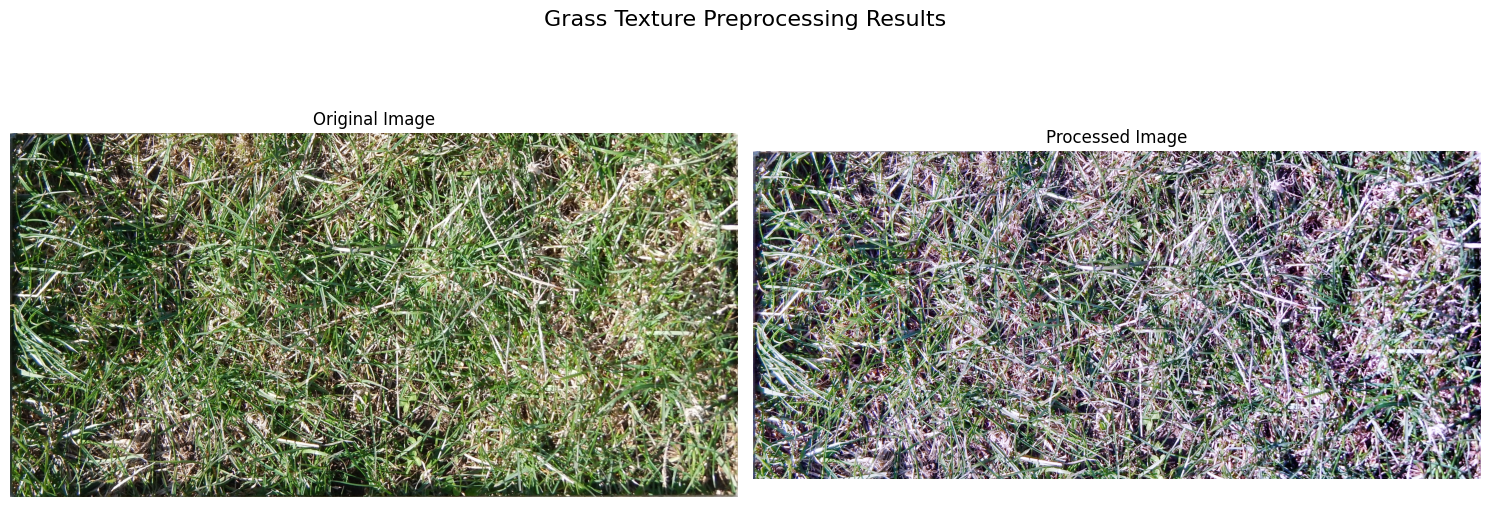

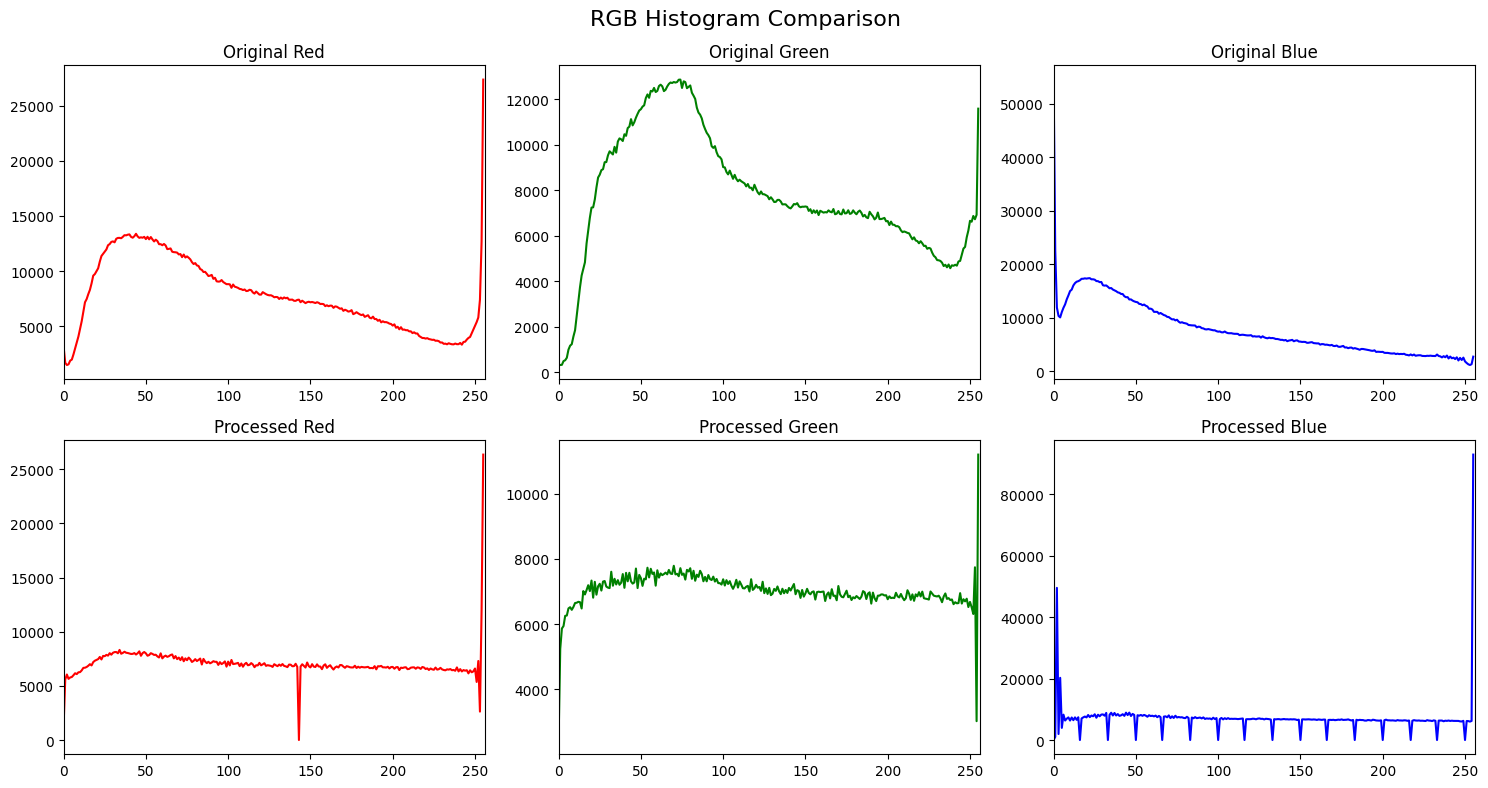

In [ ]:
# 示例图像路径（需要根据实际情况调整）
sample_image_path = '/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train/ID1011485656.jpg'

# 加载示例图像
if os.path.exists(sample_image_path):
    original_img = cv2.imread(sample_image_path)
    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    
    print("原始图像形状:", original_img.shape)
    print("原始图像数据类型:", original_img.dtype)
    print("像素值范围:", original_img.min(), "-", original_img.max())
    
    # 应用预处理
    processed_img = clean_image(original_img)
    
    print("\n处理后图像形状:", processed_img.shape)
    print("处理后像素值范围:", processed_img.min(), "-", processed_img.max())
    
    # 可视化对比
    visualize_preprocessing(original_img, processed_img, "Grass Texture Preprocessing Results")
    
    # 直方图分析
    visualize_histogram_analysis(original_img, processed_img)
    
else:
    print(f"Sample image path does not exist: {sample_image_path}")
    print("Please adjust the path or upload a sample image")

### 详细步骤演示

**逐步展示每个预处理步骤的效果**

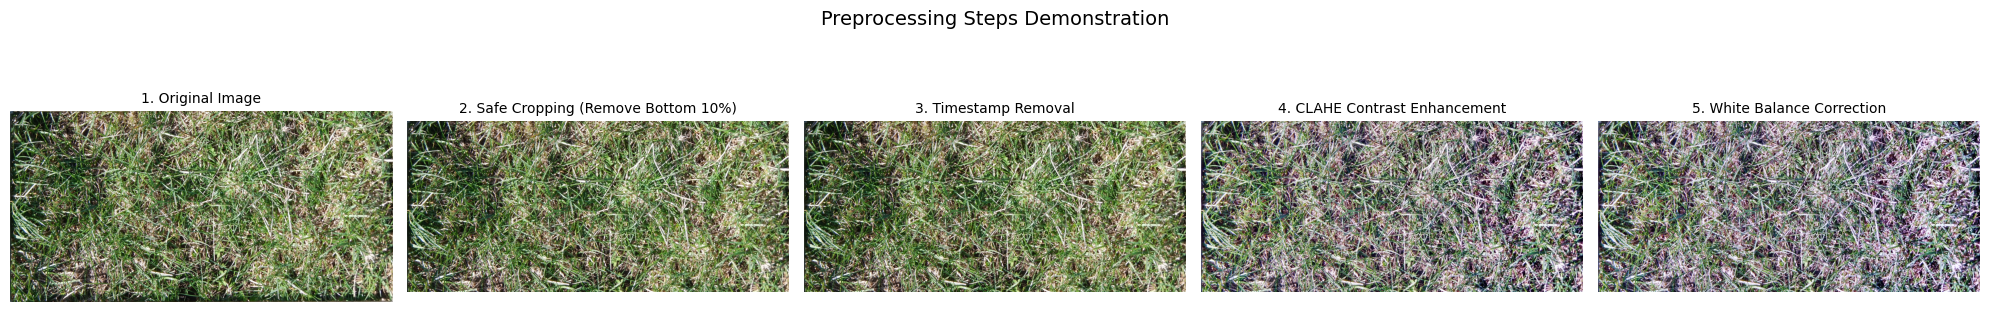

In [ ]:
def demonstrate_steps(img):
    """
    逐步演示预处理效果
    """
    steps = []
    titles = []
    
    # 原始图像
    steps.append(img)
    titles.append("1. Original Image")
    
    # 步骤1: 安全裁剪
    h, w = img.shape[:2]
    cropped = img[0:int(h*0.90), :]
    steps.append(cropped)
    titles.append("2. Safe Cropping (Remove Bottom 10%)")
    
    # 步骤2: 时间戳修复
    timestamp_removed = remove_timestamp(cropped)
    steps.append(timestamp_removed)
    titles.append("3. Timestamp Removal")
    
    # 步骤3: CLAHE
    r, g, b = cv2.split(timestamp_removed)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    r_clahe = clahe.apply(r)
    g_clahe = clahe.apply(g)
    b_clahe = clahe.apply(b)
    clahe_img = cv2.merge([r_clahe, g_clahe, b_clahe])
    steps.append(clahe_img)
    titles.append("4. CLAHE Contrast Enhancement")
    
    # 步骤4: 白平衡
    final_img = apply_white_balance(clahe_img)
    steps.append(final_img)
    titles.append("5. White Balance Correction")
    
    # 可视化所有步骤
    n_steps = len(steps)
    fig, axes = plt.subplots(1, n_steps, figsize=(4*n_steps, 4))
    
    for i, (step_img, title) in enumerate(zip(steps, titles)):
        axes[i].imshow(step_img)
        axes[i].set_title(title, fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle("Preprocessing Steps Demonstration", fontsize=14, y=0.95)
    plt.tight_layout()
    plt.show()
    
    return final_img

# 演示步骤（如果有示例图像）
if 'original_img' in locals():
    final_result = demonstrate_steps(original_img)

## 批量处理

### 批量预处理函数

Found 357 image files to process


Preprocessing images: 100%|██████████| 357/357 [00:52<00:00,  6.84it/s]



成功处理 357/357 个图像

样例处理结果:


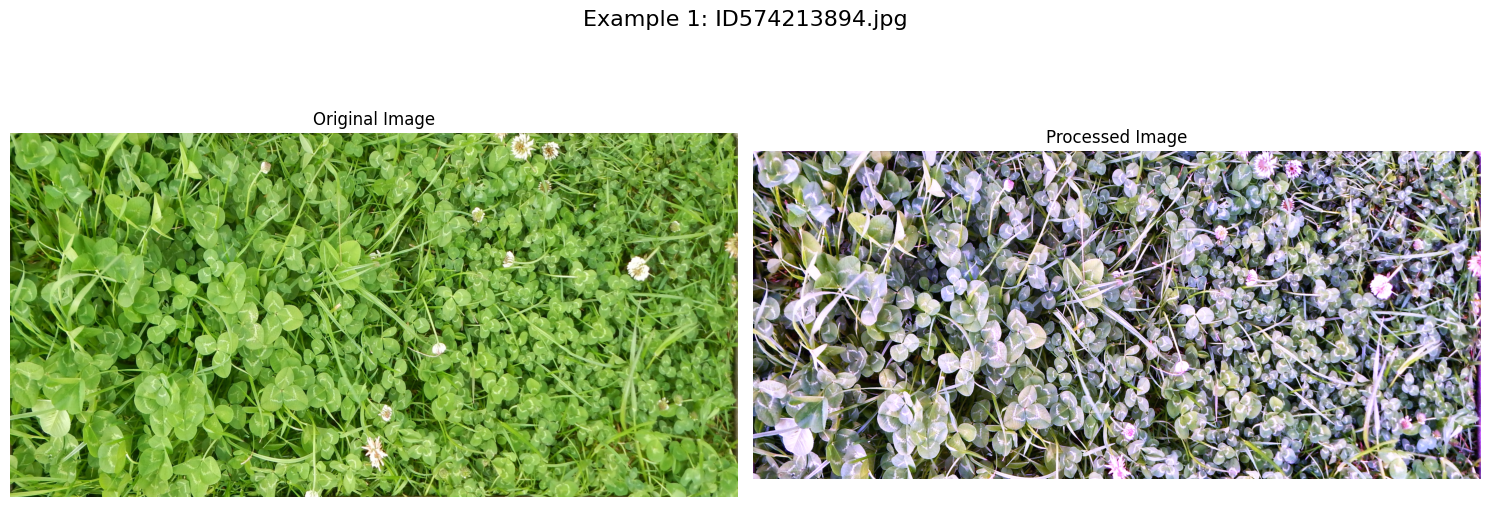

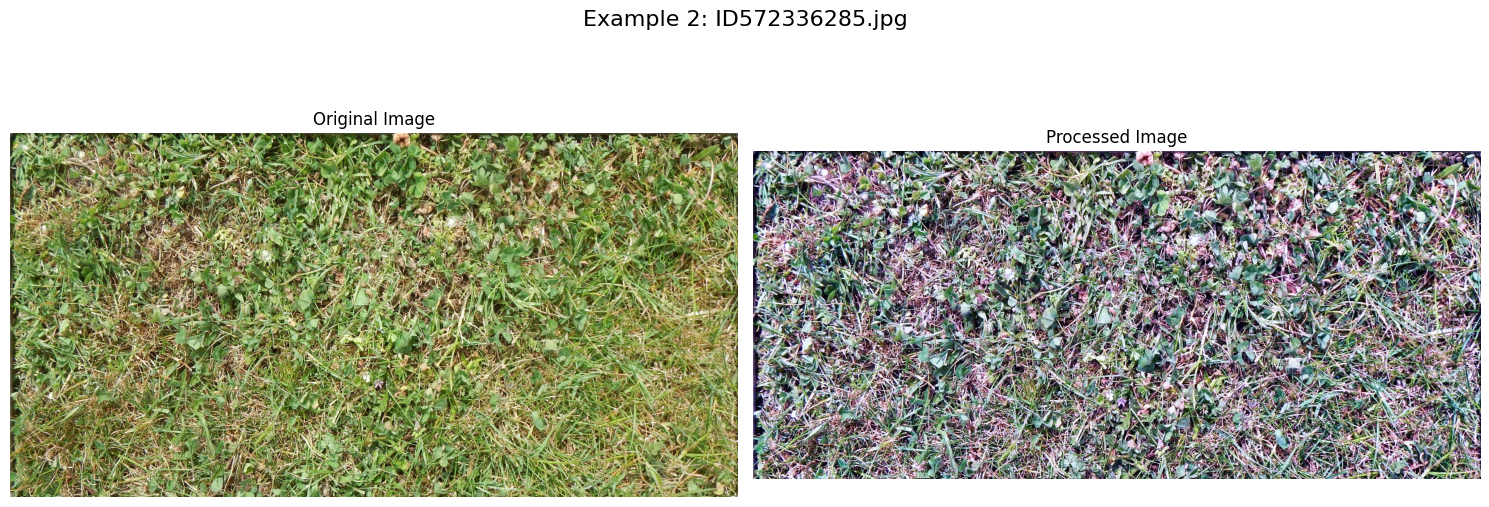

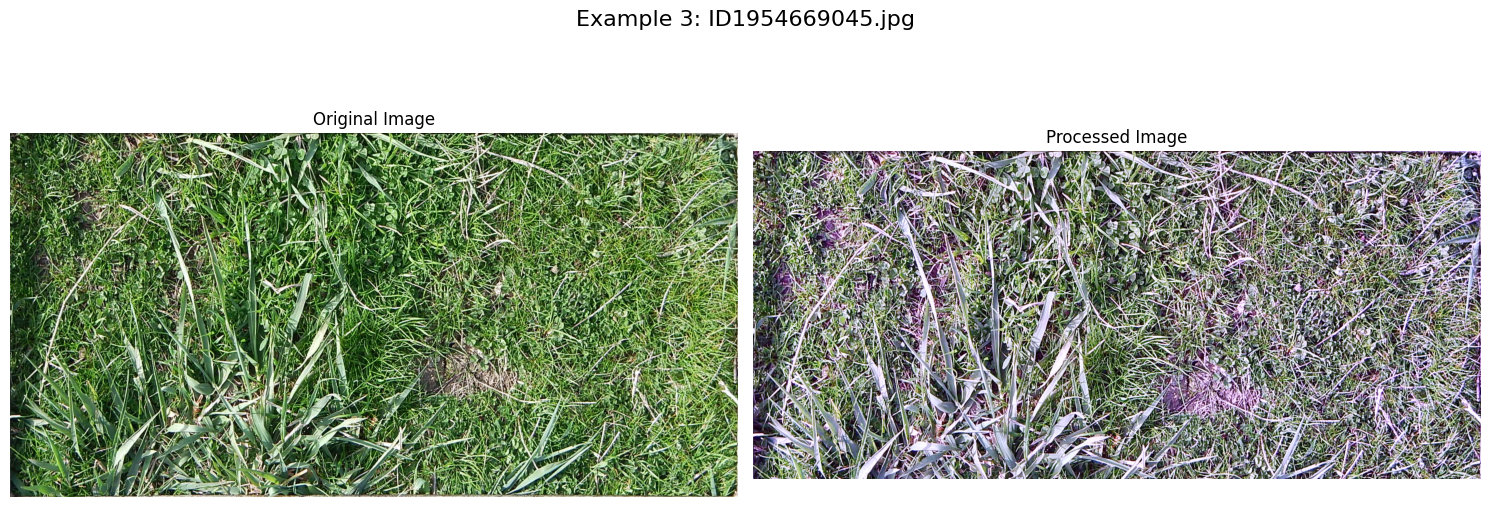

In [ ]:
def batch_preprocess_images(input_dir, output_dir, visualize_samples=5):
    """
    批量预处理图像数据集
    
    Args:
        input_dir: 输入图像目录
        output_dir: 输出目录
        visualize_samples: Number of samples to visualize
    """
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    
    # 获取所有图像文件
    image_files = glob.glob(os.path.join(input_dir, "*.jpg"))
    print(f"Found {len(image_files)} image files to process")
    
    processed_count = 0
    sample_images = []
    
    # 处理每个图像
    for img_path in tqdm(image_files, desc="Preprocessing images"):
        try:
            # 读取图像
            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Unable to read image {img_path}")
                continue
                
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # 应用预处理
            processed_img = clean_image(img)
            
            # 保存结果
            filename = Path(img_path).name
            output_path = os.path.join(output_dir, filename)
            cv2.imwrite(output_path, cv2.cvtColor(processed_img, cv2.COLOR_RGB2BGR))
            
            processed_count += 1
            
            # 保存样例用于可视化
            if len(sample_images) < visualize_samples:
                sample_images.append((img, processed_img, filename))
                
        except Exception as e:
            print(f"处理图像 {img_path} 时出错: {e}")
    
    print(f"\n成功处理 {processed_count}/{len(image_files)} 个图像")
    
    # 显示样例结果
    if sample_images:
        print("\n样例处理结果:")
        for i, (orig, proc, fname) in enumerate(sample_images):
            visualize_preprocessing(orig, proc, f"Example {i+1}: {fname}")
    
    return processed_count

# 使用示例
input_directory = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train/"
output_directory = "/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/image-processor/preprocessed_images/"
processed = batch_preprocess_images(input_directory, output_directory, visualize_samples=3)

## 质量评估和验证

### 预处理质量指标

In [ ]:
def evaluate_preprocessing_quality(original, processed):
    """
    评估预处理质量
    
    Args:
        original: 原始图像
        processed: 处理后图像
    
    Returns:
        metrics: 质量指标字典
    """
    metrics = {}
    
    # 基本统计
    metrics['original_shape'] = original.shape
    metrics['processed_shape'] = processed.shape
    metrics['size_change_percent'] = ((processed.shape[0] * processed.shape[1]) / 
                                     (original.shape[0] * original.shape[1]) - 1) * 100
    
    # 对比度分析
    gray_orig = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
    gray_proc = cv2.cvtColor(processed, cv2.COLOR_RGB2GRAY)
    
    metrics['original_contrast'] = gray_orig.std()
    metrics['processed_contrast'] = gray_proc.std()
    metrics['contrast_improvement'] = ((gray_proc.std() / gray_orig.std()) - 1) * 100
    
    # 亮度分析
    metrics['original_brightness'] = gray_orig.mean()
    metrics['processed_brightness'] = gray_proc.mean()
    
    # 颜色平衡分析
    orig_means = [original[:, :, i].mean() for i in range(3)]
    proc_means = [processed[:, :, i].mean() for i in range(3)]
    
    metrics['original_color_balance'] = np.std(orig_means) / np.mean(orig_means)
    metrics['processed_color_balance'] = np.std(proc_means) / np.mean(proc_means)
    
    return metrics

def print_quality_report(metrics):
    """
    打印质量评估报告
    """
    print("=== Preprocessing Quality Assessment Report ===")
    print(f"Image size change: {metrics['size_change_percent']:.1f}%")
    print(f"Contrast improvement: {metrics['contrast_improvement']:.1f}%")
    print(f"Original contrast: {metrics['original_contrast']:.2f}")
    print(f"Processed contrast: {metrics['processed_contrast']:.2f}")
    print(f"Color balance improvement: {metrics['original_color_balance']:.3f} → {metrics['processed_color_balance']:.3f}")
    print(f"Brightness change: {metrics['original_brightness']:.1f} → {metrics['processed_brightness']:.1f}")

# 质量评估示例
if 'original_img' in locals() and 'processed_img' in locals():
    quality_metrics = evaluate_preprocessing_quality(original_img, processed_img)
    print_quality_report(quality_metrics)

=== Preprocessing Quality Assessment Report ===
Image size change: -10.0%
Contrast improvement: 9.2%
Original contrast: 66.85
Processed contrast: 72.97
Color balance improvement: 0.140 → 0.003
Brightness change: 112.0 → 126.3


## 参数调优指南

### 关键参数及其影响

In [ ]:
def parameter_study(image_path=None):
    """
    Parameter sensitivity analysis example
    
    Args:
        image_path: Image path. If None, tries to use global variable original_img or default path
    """
    # 尝试获取图像
    img = None
    
    # 方法1: 如果提供了路径，直接加载
    if image_path is not None:
        if os.path.exists(image_path):
            img = cv2.imread(image_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            print(f"Image path does not exist: {image_path}")
            return
    
    # 方法2: 尝试使用全局变量original_img
    elif 'original_img' in globals():
        img = globals()['original_img']
    
    # 方法3: 尝试使用默认示例图像路径
    else:
        default_path = '/home/aaa/Kaggle-Series-Competition/CSIRO-Image2Biomass-Prediction/csiro-biomass/train/ID1011485656.jpg'
        if os.path.exists(default_path):
            print(f"Loading default sample image: {default_path}")
            img = cv2.imread(default_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            print("No image available. Please:")
            print("1. Load an image first, or")
            print("2. Provide image_path parameter, or")
            print("3. Ensure default image path exists")
            return
    
    if img is None:
        print("Failed to load image")
        return
    
    print("=== Parameter Tuning Study ===")
    
    # 测试不同的裁剪比例
    crop_ratios = [0.85, 0.90, 0.95]
    print("\n1. Crop Ratio Impact:")
    for ratio in crop_ratios:
        h, w = img.shape[:2]
        cropped = img[0:int(h*ratio), :]
        size_reduction = (1 - ratio) * 100
        print(f"  Crop {size_reduction:.0f}%: Size {img.shape} → {cropped.shape}")
    
    # 测试CLAHE参数
    print("\n2. CLAHE Parameter Impact:")
    test_img = img.copy()
    
    # 存储所有CLAHE测试结果
    clahe_results = []
    
    for clip_limit in [1.0, 2.0, 3.0]:
        for tile_size in [4, 8, 16]:
            r, g, b = cv2.split(test_img)
            clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(tile_size,tile_size))
            r_clahe = clahe.apply(r)
            g_clahe = clahe.apply(g)
            b_clahe = clahe.apply(b)
            result = cv2.merge([r_clahe, g_clahe, b_clahe])
            contrast = cv2.cvtColor(result, cv2.COLOR_RGB2GRAY).std()
            clahe_results.append({
                'clip_limit': clip_limit,
                'tile_size': tile_size,
                'contrast': contrast
            })
            print(f"  CLAHE(clip={clip_limit}, tile={tile_size}): Contrast = {contrast:.2f}")
    
    # 基于测试结果动态推荐最佳参数
    print("\n3. Recommended Parameters (Based on Test Results):")
    
    # 推荐裁剪比例：保持0.90（移除底部10%），这是基于经验值
    best_crop_ratio = 0.90
    print(f"  - Crop ratio: {best_crop_ratio} (Remove bottom {(1-best_crop_ratio)*100:.0f}%)")
    
    # 推荐最佳CLAHE参数：选择对比度最高的组合
    if clahe_results:
        best_clahe = max(clahe_results, key=lambda x: x['contrast'])
        print(f"  - CLAHE clipLimit: {best_clahe['clip_limit']} (Best contrast: {best_clahe['contrast']:.2f})")
        print(f"  - CLAHE tileGridSize: ({best_clahe['tile_size']},{best_clahe['tile_size']})")
        
        # 如果最佳参数不是默认值，给出说明
        if best_clahe['clip_limit'] != 2.0 or best_clahe['tile_size'] != 8:
            print(f"    Note: Best parameters differ from defaults (clipLimit=2.0, tileGridSize=(8,8))")
            print(f"    Consider using best parameters for this specific image type.")
    
    # 时间戳颜色范围保持不变（基于HSV颜色空间特性）
    print("  - Timestamp color range: H[5°,25°], S>150, V>150")

# 运行参数研究
parameter_study()

=== Parameter Tuning Study ===

1. Crop Ratio Impact:
  Crop 15%: Size (1000, 2000, 3) → (850, 2000, 3)
  Crop 10%: Size (1000, 2000, 3) → (900, 2000, 3)
  Crop 5%: Size (1000, 2000, 3) → (950, 2000, 3)

2. CLAHE Parameter Impact:
  CLAHE(clip=1.0, tile=4): Contrast = 70.83
  CLAHE(clip=1.0, tile=8): Contrast = 70.61
  CLAHE(clip=1.0, tile=16): Contrast = 70.24
  CLAHE(clip=2.0, tile=4): Contrast = 72.49
  CLAHE(clip=2.0, tile=8): Contrast = 72.36
  CLAHE(clip=2.0, tile=16): Contrast = 72.05
  CLAHE(clip=3.0, tile=4): Contrast = 72.31
  CLAHE(clip=3.0, tile=8): Contrast = 72.20
  CLAHE(clip=3.0, tile=16): Contrast = 71.96

3. Recommended Parameters (Based on Test Results):
  - Crop ratio: 0.9 (Remove bottom 10%)
  - CLAHE clipLimit: 2.0 (Best contrast: 72.49)
  - CLAHE tileGridSize: (4,4)
    Note: Best parameters differ from defaults (clipLimit=2.0, tileGridSize=(8,8))
    Consider using best parameters for this specific image type.
  - Timestamp color range: H[5°,25°], S>150, V>150


## 总结

### 方法优势

1. **系统性预处理**：
   - 解决农业图像特有的伪影问题
   - 标准化图像条件
   - 提高模型泛化能力

2. **理论基础扎实**：
   - 基于图像处理经典算法
   - 参数选择有理论依据
   - 效果可预测和控制

3. **计算效率高**：
   - 预处理步骤相对简单
   - 可以并行处理
   - 内存占用低

### 关键技术组件

| 组件 | 技术 | 目的 | 参数 |
|------|------|------|------|
| 安全裁剪 | 几何变换 | 移除伪影 | 裁剪90%高度 |
| 时间戳修复 | 图像修复 | 去除文本 | HSV阈值+TELEA |
| CLAHE | 直方图均衡 | 增强对比度 | clipLimit=2.0 |
| 白平衡 | 颜色校正 | 校正色偏 | 灰度世界算法 |

### 应用效果

**预期改进：**
- LB 0.60 → 0.62 (根据竞赛经验)
- 减少模型对无关特征的学习
- 提高在不同条件下图像的鲁棒性
- 增强生物量相关纹理特征

### 局限性和注意事项

1. **参数依赖性**：
   - 橙色阈值可能需要根据具体数据集调整
   - 裁剪比例可能因相机设置而异

2. **潜在风险**：
   - 过度裁剪可能丢失重要植被信息
   - 白平衡可能改变自然颜色特征
   - CLAHE可能放大噪声

3. **数据集特定性**：
   - 参数需要根据具体竞赛数据集调优
   - 建议在验证集上评估效果

### 最佳实践建议

1. **逐步应用**：从简单预处理开始，逐步添加复杂步骤
2. **效果验证**：使用视觉检查和定量指标评估
3. **参数调优**：在小数据集上优化参数
4. **流水线化**：将预处理集成到数据加载器中
5. **版本控制**：保存预处理参数和结果

### 扩展应用

- **其他农业应用**：病虫害检测、生长阶段分类
- **环境监测**：植被覆盖分析、生态系统评估
- **遥感图像**：无人机航拍图像预处理
- **工业检测**：表面缺陷检测预处理

### 未来改进方向

1. **自适应参数**：基于图像内容自动调整参数
2. **深度学习预处理**：使用神经网络学习最佳预处理
3. **多尺度处理**：不同分辨率下的联合优化
4. **时序一致性**：保持时间序列图像之间的一致性

该预处理方案提供了一个从理论到实践的完整框架，特别适用于农业和环境监测领域的计算机视觉任务。